Figure S8: Number of credible sets mapped per PC phenotype (pcQTL) and expression phenotype (eQTL). Dotted red line shows L=10, the maximum number of credible sets possible with SuSiE as run. 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from tqdm.auto import tqdm 
tqdm.pandas()

import yaml
config_path= '/home/klawren/oak/pcqtls/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append('/home/klawren/oak/pcqtls/workflow/scripts')
from utils import *

%config InlineBackend.figure_formats = ['png']
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

# Define colors for eQTL vs pcQTL
qtl_colors = {'eQTL': '#6FA287', 'pcQTL': '#620059'}

In [7]:
# Load SuSiE annotated results across all tissues
print("Loading SuSiE results...")
susie_annotated = load_across_tissues(config, load_susie_annotated)
print(f"Loaded {len(susie_annotated)} total SuSiE results")

# Add QTL type column
susie_annotated['qtl_type'] = susie_annotated['type'].map({'eqtl': 'eQTL', 'pcqtl': 'pcQTL'})

# Count credible sets per phenotype
cs_counts_per_phenotype = susie_annotated.groupby(['phenotype_id', 'qtl_type', 'tissue_id'])['cs_id'].nunique().reset_index()
cs_counts_per_phenotype.columns = ['phenotype_id', 'qtl_type', 'tissue_id', 'num_credible_sets']

print(f"Analyzing {len(cs_counts_per_phenotype)} phenotypes")
print(f"eQTL phenotypes: {len(cs_counts_per_phenotype[cs_counts_per_phenotype['qtl_type'] == 'eQTL'])}")
print(f"pcQTL phenotypes: {len(cs_counts_per_phenotype[cs_counts_per_phenotype['qtl_type'] == 'pcQTL'])}")

Loading SuSiE results...
Loaded 899228 total SuSiE results
Analyzing 26850 phenotypes
eQTL phenotypes: 13843
pcQTL phenotypes: 13007


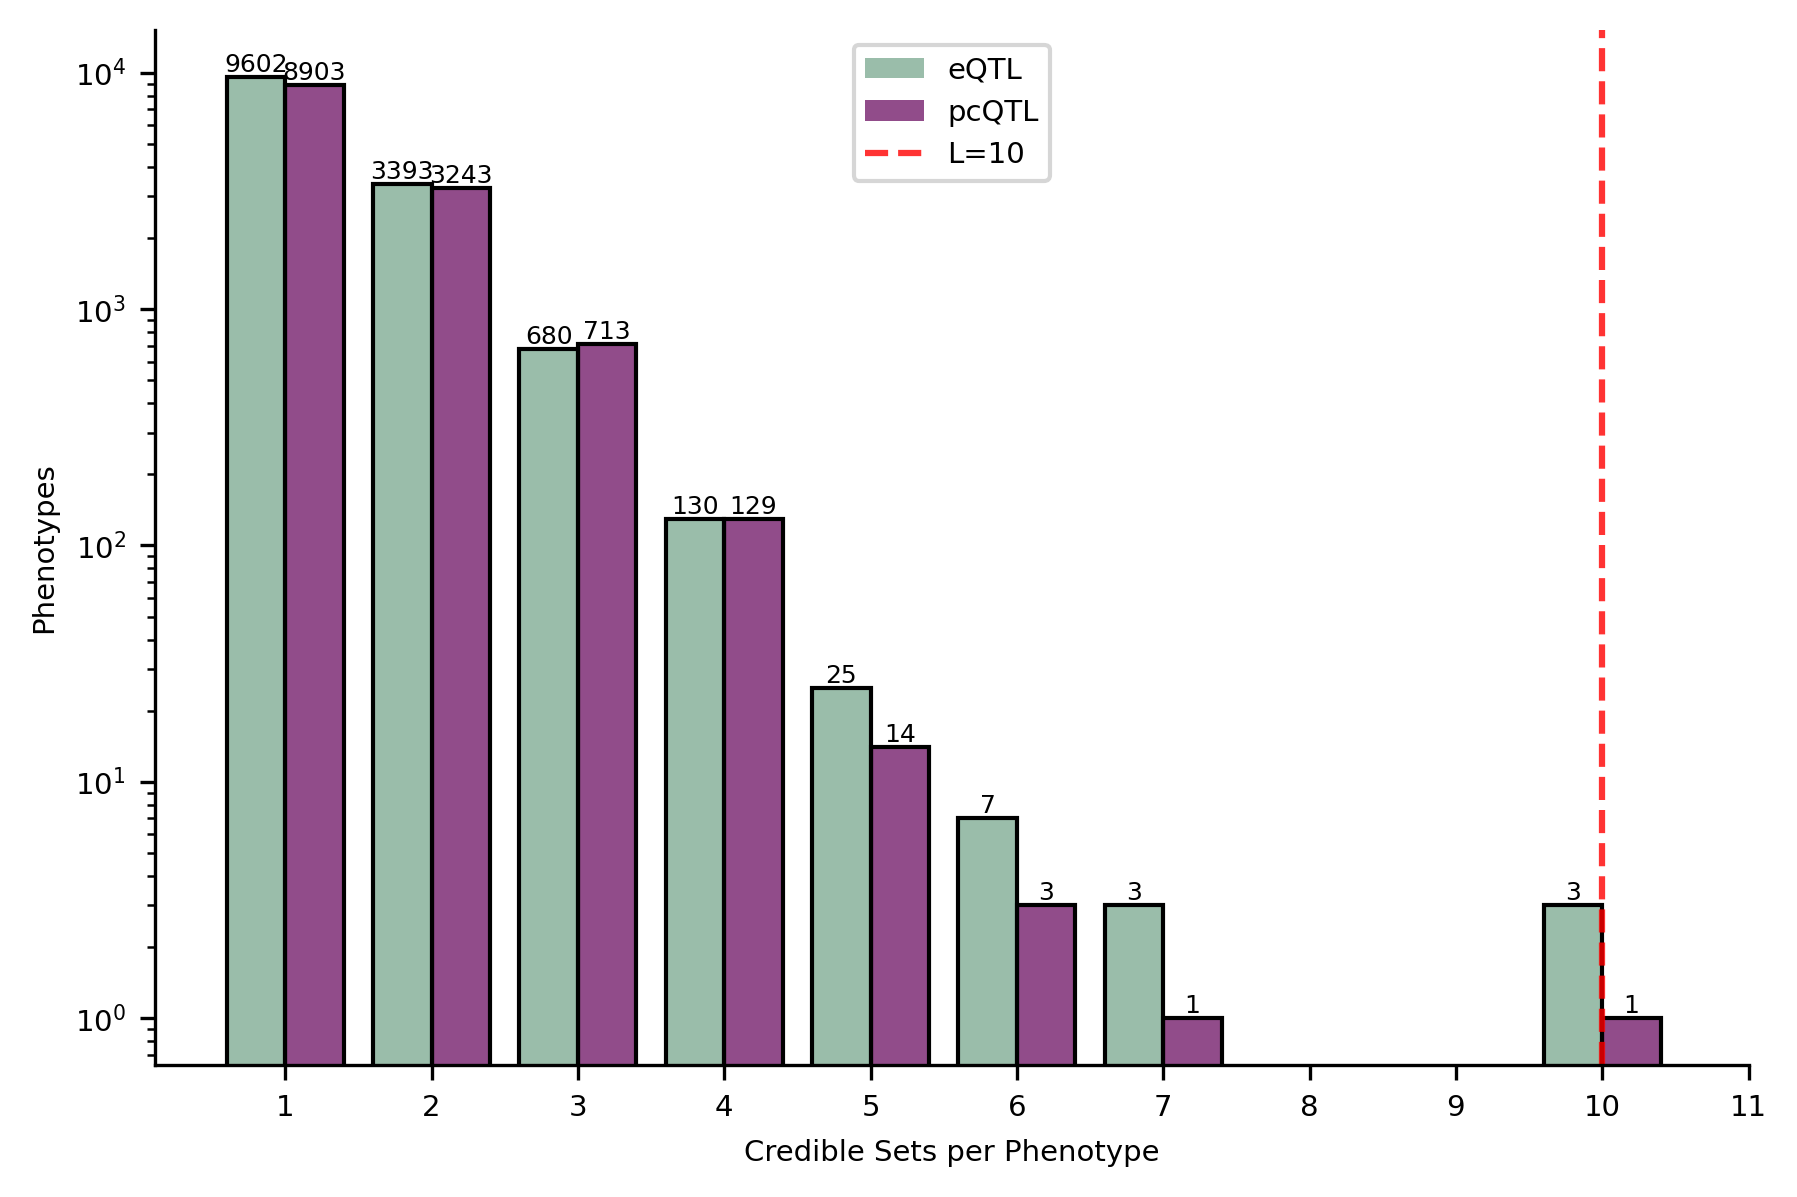

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Create histogram using seaborn
sns.histplot(cs_counts_per_phenotype, x='num_credible_sets', discrete=True, hue='qtl_type', 
             palette=qtl_colors, alpha=0.7, ax=ax, multiple='dodge', shrink=0.8)

# Set y-axis to log scale
ax.set_yscale('log')

# Add annotations to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=6)

ax.set_xticks(range(1, 12))

ax.set_xlabel('Credible Sets per Phenotype')
ax.set_ylabel('Phenotypes')
ax.spines[['top', 'right']].set_visible(False)

# Add vertical line at L=10
ax.axvline(x=10, color='red', linestyle='--', alpha=0.8, label='L=10 (SuSiE default)')

legend_elements = [
    Patch(facecolor=qtl_colors['eQTL'], alpha=0.7, label='eQTL'),
    Patch(facecolor=qtl_colors['pcQTL'], alpha=0.7, label='pcQTL'),
    Line2D([0], [0], color='red', linestyle='--', alpha=0.8, label='L=10')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s8.pdf', 
            transparent=True, bbox_inches='tight')
plt.show()

In [9]:
print(" {} ({:.2f}%) phenotypes have more than 9 credible sets".format(len(cs_counts_per_phenotype[cs_counts_per_phenotype['num_credible_sets'] > 9]), 
    len(cs_counts_per_phenotype[cs_counts_per_phenotype['num_credible_sets'] > 9])/len(cs_counts_per_phenotype)*100))


 4 (0.01%) phenotypes have more than 9 credible sets
